In [1]:
import pandas as pd

df = pd.read_csv('query.csv')
print(df.shape)
print(df.head())
print(df.columns.tolist())

(992, 22)
                       time  latitude  longitude    depth  mag magType    nst  \
0  2026-05-08T17:50:14.413Z   -4.6052   -77.9947   37.840  4.3      mb   29.0   
1  2026-05-06T22:06:49.692Z   -2.2614   -79.1810   96.810  4.6      mb   46.0   
2  2026-04-26T08:10:19.615Z    6.7280   -72.9670  168.894  4.2      mb   36.0   
3  2026-04-21T02:22:21.410Z    0.3364   -78.3232  129.427  5.2     mww  108.0   
4  2026-04-18T14:05:01.402Z    7.1007   -75.3286   66.025  4.3      mb   46.0   

   gap   dmin   rms  ...                   updated  \
0  125  2.319  0.48  ...  2026-05-08T18:49:23.040Z   
1  104  0.217  0.68  ...  2026-05-07T15:24:06.057Z   
2   97  2.305  0.82  ...  2026-05-07T12:29:02.040Z   
3   24  0.360  0.97  ...  2026-04-22T02:41:42.601Z   
4   93  2.455  0.62  ...  2026-05-09T16:30:14.040Z   

                               place        type horizontalError depthError  \
0     120 km SE of Yantzaza, Ecuador  earthquake            8.76      6.292   
1    25 km NE of La 

In [2]:
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2026-05-08T17:50:14.413Z,-4.6052,-77.9947,37.840,4.3,mb,29.0,125,2.319,0.48,...,2026-05-08T18:49:23.040Z,"120 km SE of Yantzaza, Ecuador",earthquake,8.76,6.292,0.119,20,reviewed,us,us
1,2026-05-06T22:06:49.692Z,-2.2614,-79.1810,96.810,4.6,mb,46.0,104,0.217,0.68,...,2026-05-07T15:24:06.057Z,"25 km NE of La Troncal, Ecuador",earthquake,6.44,4.163,0.054,104,reviewed,us,us
2,2026-04-26T08:10:19.615Z,6.7280,-72.9670,168.894,4.2,mb,36.0,97,2.305,0.82,...,2026-05-07T12:29:02.040Z,"3 km SSE of Cepitá, Colombia",earthquake,10.65,9.263,0.091,34,reviewed,us,us
3,2026-04-21T02:22:21.410Z,0.3364,-78.3232,129.427,5.2,mww,108.0,24,0.360,0.97,...,2026-04-22T02:41:42.601Z,"7 km WNW of Cotacachi, Ecuador",earthquake,6.76,3.704,0.045,47,reviewed,us,us
4,2026-04-18T14:05:01.402Z,7.1007,-75.3286,66.025,4.3,mb,46.0,93,2.455,0.62,...,2026-05-09T16:30:14.040Z,"13 km NNW of Campamento, Colombia",earthquake,8.95,9.174,0.090,35,reviewed,us,us


In [3]:
df.columns.tolist()

['time',
 'latitude',
 'longitude',
 'depth',
 'mag',
 'magType',
 'nst',
 'gap',
 'dmin',
 'rms',
 'net',
 'id',
 'updated',
 'place',
 'type',
 'horizontalError',
 'depthError',
 'magError',
 'magNst',
 'status',
 'locationSource',
 'magSource']

In [4]:
# Convertir tiempo a formato fecha
df['time'] = pd.to_datetime(df['time'])

# Información básica
print("Rango de fechas:")
print(df['time'].min(), "hasta", df['time'].max())

print("\nEstadísticas de magnitud:")
print(df['mag'].describe())

print("\nEstadísticas de profundidad:")
print(df['depth'].describe())

print("\n¿Cuántos sismos por país aproximadamente?")
print(df['place'].str.extract(r',\s*(.+)$')[0].value_counts().head(10))

Rango de fechas:
2020-01-04 13:52:56.648000+00:00 hasta 2026-05-08 17:50:14.413000+00:00

Estadísticas de magnitud:
count    992.000000
mean       4.451411
std        0.410677
min        2.500000
25%        4.300000
50%        4.400000
75%        4.600000
max        7.500000
Name: mag, dtype: float64

Estadísticas de profundidad:
count    992.000000
mean      88.803941
std       65.155390
min        1.702000
25%       10.000000
50%      100.779500
75%      152.611750
max      222.549000
Name: depth, dtype: float64

¿Cuántos sismos por país aproximadamente?
Colombia                              604
Ecuador                               202
Venezuela                              67
Peru                                   58
Panama                                 31
Bonaire, Saint Eustatius and Saba       1
Name: 0, dtype: int64


<ipython-input-5-9b23d3da8973>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  col['year'] = col['time'].dt.year


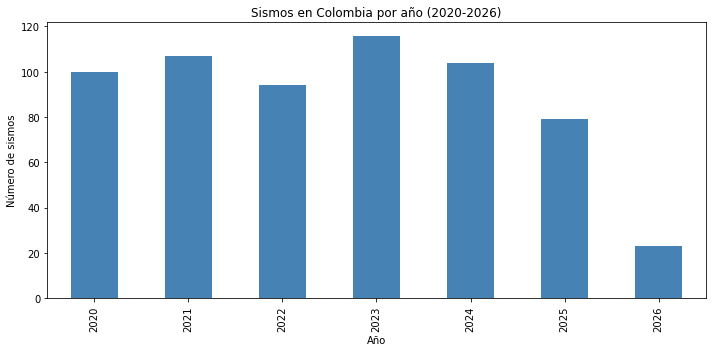

year
2020    100
2021    107
2022     94
2023    116
2024    104
2025     79
2026     23
dtype: int64


In [5]:
import matplotlib.pyplot as plt

# Filtrar solo Colombia
col = df[df['place'].str.contains('Colombia', na=False)]

# Sismos por año
col['year'] = col['time'].dt.year
sismos_año = col.groupby('year').size()

# Graficar
plt.figure(figsize=(10, 5))
sismos_año.plot(kind='bar', color='steelblue')
plt.title('Sismos en Colombia por año (2020-2026)')
plt.xlabel('Año')
plt.ylabel('Número de sismos')
plt.tight_layout()
plt.savefig('sismos_colombia.png')
plt.show()

print(sismos_año)

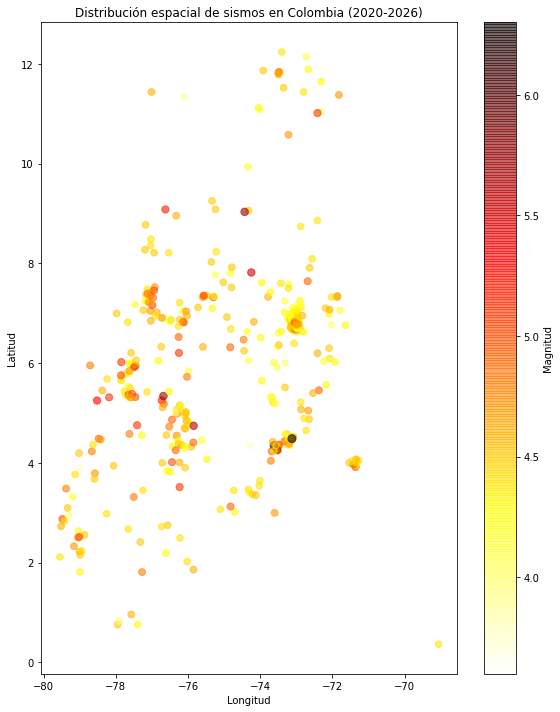

In [6]:
# Mapa de puntos de sismos en Colombia
plt.figure(figsize=(8, 10))
scatter = plt.scatter(
    col['longitude'], 
    col['latitude'], 
    c=col['mag'], 
    cmap='hot_r', 
    s=col['mag']*10, 
    alpha=0.6
)
plt.colorbar(scatter, label='Magnitud')
plt.title('Distribución espacial de sismos en Colombia (2020-2026)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.tight_layout()
plt.savefig('mapa_sismos.png')
plt.show()

In [7]:
pip install contextily geopandas


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\jjmor\anaconda3\lib\site-packages\pip\_internal\cli\base_command.py", line 105, in _run_wrapper
    status = _inner_run()
  File "c:\Users\jjmor\anaconda3\lib\site-packages\pip\_internal\cli\base_command.py", line 96, in _inner_run
    return self.run(options, args)
  File "c:\Users\jjmor\anaconda3\lib\site-packages\pip\_internal\cli\req_command.py", line 67, in wrapper
    return func(self, options, args)
  File "c:\Users\jjmor\anaconda3\lib\site-packages\pip\_internal\commands\install.py", line 483, in run
    installed_versions[distribution.canonical_name] = distribution.version
  File "c:\Users\jjmor\anaconda3\lib\site-packages\pip\_internal\metadata\pkg_resources.py", line 192, in version
    return parse_version(self._dist.version)
  File "c:\Users\jjmor\anaconda3\lib\site-packages\pip\_v

   ---------------------------------------- 1.1/1.1 MB 13.2 MB/s eta 0:00:00
   ---------------------------------------- 24.5/24.5 MB 27.7 MB/s eta 0:00:00
   ---------------------------------------- 5.1/5.1 MB 19.5 MB/s eta 0:00:00
   ---------------------------------------- 1.5/1.5 MB 19.0 MB/s eta 0:00:00
   ---------------------------------------- 24.8/24.8 MB 26.6 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 7.1.2
    Uninstalling click-7.1.2:
      Successfully uninstalled click-7.1.2


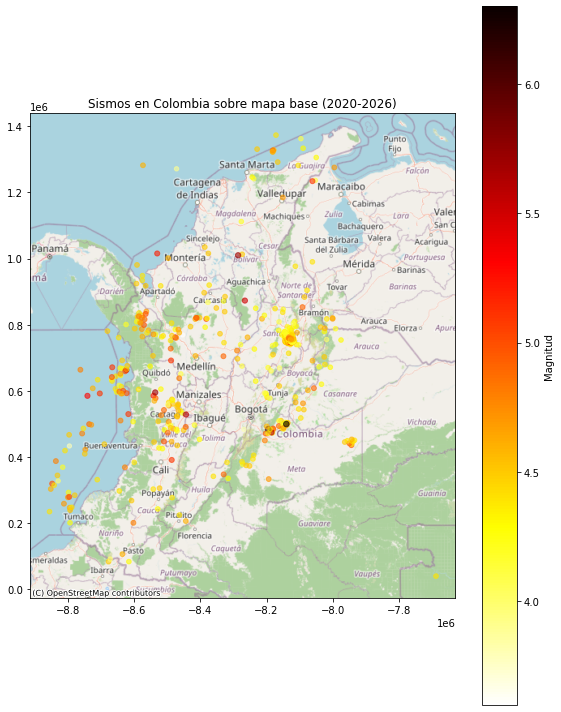

In [8]:
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point

# Crear GeoDataFrame
gdf = gpd.GeoDataFrame(
    col, 
    geometry=gpd.points_from_xy(col['longitude'], col['latitude']),
    crs='EPSG:4326'
).to_crs(epsg=3857)

# Graficar
fig, ax = plt.subplots(figsize=(8, 10))
gdf.plot(
    ax=ax,
    column='mag',
    cmap='hot_r',
    markersize=gdf['mag']*5,
    alpha=0.6,
    legend=True,
    legend_kwds={'label': 'Magnitud'}
)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_title('Sismos en Colombia sobre mapa base (2020-2026)')
plt.tight_layout()
plt.savefig('mapa_sismos_base.png', dpi=150)
plt.show()

<ipython-input-9-d39f228c0f4d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  col['zona'] = col['longitude'].apply(


                      count        mean        std   min     25%       50%  \
zona                                                                         
Costa Pacífica        114.0   29.076307  27.502308  9.70  10.000   15.0815   
Interior continental  509.0  116.776664  57.676649  5.06  65.712  147.9300   

                            75%      max  
zona                                      
Costa Pacífica         40.52625  136.419  
Interior continental  156.31300  190.290  


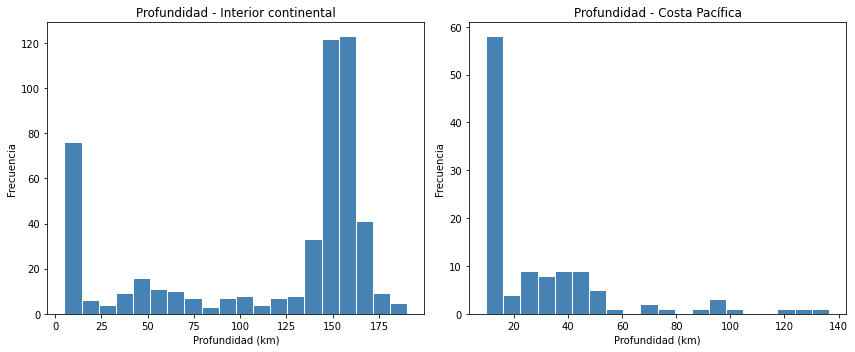

In [9]:
# Separar sismos costa pacífica vs interior
col['zona'] = col['longitude'].apply(
    lambda x: 'Costa Pacífica' if x < -76.5 else 'Interior continental'
)

# Comparar profundidades
print(col.groupby('zona')['depth'].describe())

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, zona in enumerate(col['zona'].unique()):
    subset = col[col['zona'] == zona]
    axes[i].hist(subset['depth'], bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Profundidad - {zona}')
    axes[i].set_xlabel('Profundidad (km)')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('profundidad_por_zona.png', dpi=150)
plt.show()

In [10]:
# Resumen del hallazgo
resumen = col.groupby('zona')['depth'].agg(['mean', 'median', 'min', 'max'])
resumen.columns = ['Promedio', 'Mediana', 'Mínimo', 'Máximo']
print("\nResumen de profundidades por zona:")
print(resumen.round(1))


Resumen de profundidades por zona:
                      Promedio  Mediana  Mínimo  Máximo
zona                                                   
Costa Pacífica            29.1     15.1     9.7   136.4
Interior continental     116.8    147.9     5.1   190.3


In [11]:
# ============================================
# HALLAZGO 1: Distribución espacial de sismos
# Colombia concentra el 61% de la sismicidad 
# regional (604 de 992 eventos, 2020-2026)
# ============================================

# ============================================
# HALLAZGO 2: Profundidad por zona tectónica
# Costa Pacífica: sismos someros (mediana 15 km)
# → Ruptura en interfaz de subducción Nazca-Suramérica
# Interior continental: sismos profundos (mediana 148 km)
# → Zona de Wadati-Benioff, placa de Nazca subducida
# ============================================

print("Resumen ejecutivo del análisis:")
print(f"- Total sismos Colombia: {len(col)}")
print(f"- Período: {col['time'].dt.year.min()} - {col['time'].dt.year.max()}")
print(f"- Sismo máximo registrado: {col['mag'].max()} Mw")
print(f"- Profundidad promedio Costa Pacífica: {col[col['zona']=='Costa Pacífica']['depth'].median():.1f} km")
print(f"- Profundidad promedio Interior: {col[col['zona']=='Interior continental']['depth'].median():.1f} km")

Resumen ejecutivo del análisis:
- Total sismos Colombia: 623
- Período: 2020 - 2026
- Sismo máximo registrado: 6.3 Mw
- Profundidad promedio Costa Pacífica: 15.1 km
- Profundidad promedio Interior: 147.9 km


<ipython-input-12-46f075c38b1d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  col['month'] = col['time'].dt.month
<ipython-input-12-46f075c38b1d>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  col['year'] = col['time'].dt.year


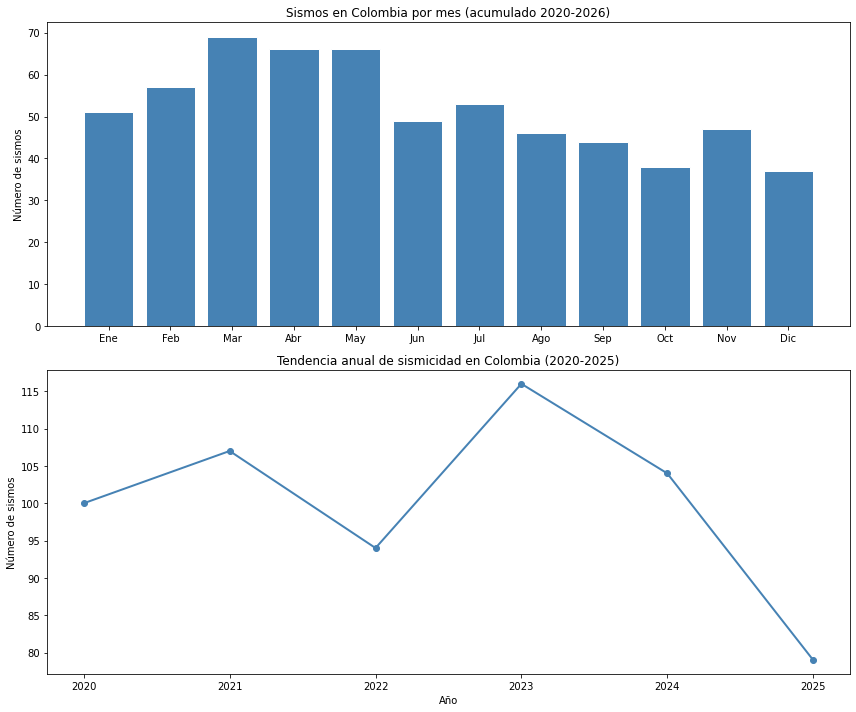


Sismos por mes:
Ene    51
Feb    57
Mar    69
Abr    66
May    66
Jun    49
Jul    53
Ago    46
Sep    44
Oct    38
Nov    47
Dic    37
dtype: int64

Sismos por año:
year
2020    100
2021    107
2022     94
2023    116
2024    104
2025     79
dtype: int64


In [12]:
# Análisis temporal
col['month'] = col['time'].dt.month
col['year'] = col['time'].dt.year

# Sismos por mes (promedio histórico)
sismos_mes = col.groupby('month').size()
meses = ['Ene','Feb','Mar','Abr','May','Jun',
         'Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Gráfica 1: promedio por mes
axes[0].bar(range(1,13), sismos_mes, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(meses)
axes[0].set_title('Sismos en Colombia por mes (acumulado 2020-2026)')
axes[0].set_ylabel('Número de sismos')

# Gráfica 2: tendencia anual con línea
sismos_año = col[col['year'] < 2026].groupby('year').size()
axes[1].plot(sismos_año.index, sismos_año.values, 
             marker='o', color='steelblue', linewidth=2)
axes[1].set_title('Tendencia anual de sismicidad en Colombia (2020-2025)')
axes[1].set_ylabel('Número de sismos')
axes[1].set_xlabel('Año')

plt.tight_layout()
plt.savefig('analisis_temporal.png', dpi=150)
plt.show()

print("\nSismos por mes:")
print(pd.Series(sismos_mes.values, index=meses))
print("\nSismos por año:")
print(sismos_año)

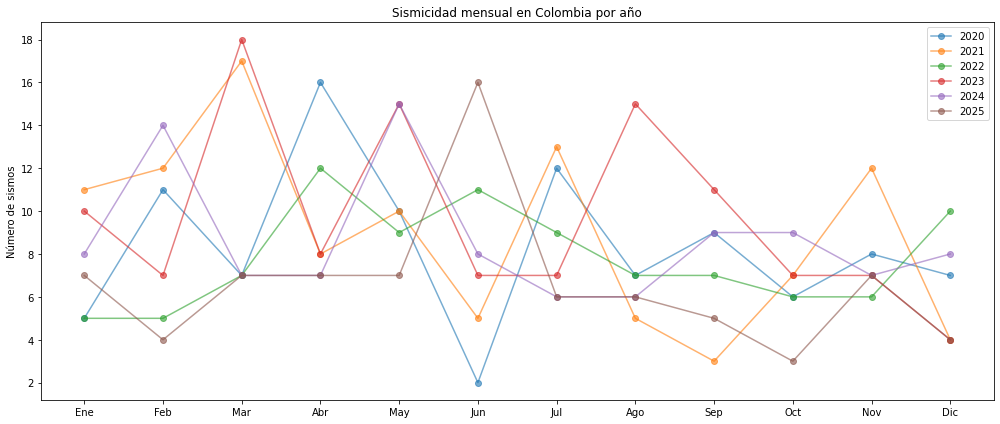

Sismos en abril por año:
year
2020    16
2021     8
2022    12
2023     8
2024     7
2025     7
2026     8
Name: Abr, dtype: int64

Promedio abril: 9.4
Promedio resto de meses: 7.2


In [13]:
# Desglosar el pico de abril por año
pivot = col.groupby(['year', 'month']).size().unstack(fill_value=0)
pivot.columns = meses

fig, ax = plt.subplots(figsize=(14, 6))
for year in pivot.index:
    if year < 2026:
        ax.plot(meses, pivot.loc[year], marker='o', alpha=0.6, label=str(year))

ax.set_title('Sismicidad mensual en Colombia por año')
ax.set_ylabel('Número de sismos')
ax.legend()
plt.tight_layout()
plt.savefig('temporal_por_año.png', dpi=150)
plt.show()

# ¿El pico de abril es consistente?
print("Sismos en abril por año:")
print(pivot['Abr'])
print(f"\nPromedio abril: {pivot['Abr'].mean():.1f}")
print(f"Promedio resto de meses: {pivot.drop(columns='Abr').mean().mean():.1f}")


In [14]:
print("=" * 50)
print("HALLAZGO 3: Análisis temporal")
print("=" * 50)
print("- No se observa estacionalidad mensual clara")
print("- El aparente pico de abril está influenciado")
print("  por actividad inusual en 2020 (16 eventos)")
print(f"- Promedio mensual general: {col.groupby('month').size().mean():.1f} sismos")
print("- La sismicidad anual no muestra tendencia")
print("  creciente ni decreciente en 2020-2025")

HALLAZGO 3: Análisis temporal
- No se observa estacionalidad mensual clara
- El aparente pico de abril está influenciado
  por actividad inusual en 2020 (16 eventos)
- Promedio mensual general: 51.9 sismos
- La sismicidad anual no muestra tendencia
  creciente ni decreciente en 2020-2025
